In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
NUMBER_OF_SATELLITES_PER_ORBIT = 22

In [3]:
df = pd.read_csv('../generated/2024_03_29,14_41_22#Starlink#1000ms#8000s.csv')
df

,TimeStamp,satelliteId,orbitId,X,Y,Z,Anomaly
0,0,Starlink-1-11,550km-5'-53',-6.779805e+06,-1.188798e+06,-7.874358e+05,3.284392
1,0,Starlink-2-15,550km-10'-53',-2.175737e+06,-4.234820e+06,-5.033044e+06,4.283990
2,0,Starlink-0-13,550km-0'-53',-5.828318e+06,-2.254178e+06,-2.991395e+06,3.712791
3,0,Starlink-2-3,550km-10'-53',3.920860e+06,3.891028e+06,4.181604e+06,0.856798
4,0,Starlink-2-16,550km-10'-53',-2.543483e+05,-4.235531e+06,-5.476736e+06,4.569589
...,...,...,...,...,...,...,...
528061,8000000,Starlink-2-15,550km-10'-53',5.418082e+06,3.185606e+06,2.914680e+06,13.121174
528062,8000000,Starlink-2-11,550km-10'-53',6.079893e+06,-1.274989e+06,-3.067306e+06,11.978776
528063,8000000,Starlink-0-6,550km-0'-53',-2.980985e+06,-3.763764e+06,-4.994683e+06,10.550780
528064,8000000,Starlink-2-21,550km-10'-53',-4.937775e+06,2.374037e+06,4.240446e+06,14.834770


In [4]:
base_satellite = np.random.choice(df['satelliteId'].unique())
other_satellites = np.array([])
for orbit in df['orbitId'].unique():
    other_satellites = np.append(other_satellites, np.random.choice(df[df.orbitId == orbit].satelliteId.unique()))
print(base_satellite)
print(other_satellites)

Starlink-0-21
['Starlink-1-14' 'Starlink-2-0' 'Starlink-0-13']


In [5]:
base_sattelite_positions = df[df.satelliteId == base_satellite].reset_index()[['TimeStamp', 'X', 'Y', 'Z']]
distance_suffixes = []
for other_satellite in other_satellites:
    other_satellite_positions = df[df.satelliteId == other_satellite].reset_index()
    other_satellite_orbit = other_satellite_positions.orbitId.unique()[0]
    other_satellite_positions = other_satellite_positions[['TimeStamp', 'X', 'Y', 'Z']]
    base_sattelite_positions = pd.merge(base_sattelite_positions, other_satellite_positions, on='TimeStamp', suffixes=('', f"_{other_satellite_orbit}"))
    distance_suffixes.append(f"distance_{other_satellite_orbit}")
    base_sattelite_positions[f"distance_{other_satellite_orbit}"] = base_sattelite_positions.apply(
    lambda row: np.sqrt((row[f'X_{other_satellite_orbit}'] - row[f'X'])**2 + 
                      (row[f'Y_{other_satellite_orbit}'] - row[f'Y'])**2 + 
                      (row[f'Z_{other_satellite_orbit}'] - row[f'Z'])**2), axis=1)  

base_sattelite_positions

,TimeStamp,X,Y,Z,X_550km-5'-53',Y_550km-5'-53',Z_550km-5'-53',distance_550km-5'-53',X_550km-10'-53',Y_550km-10'-53',Z_550km-10'-53',distance_550km-10'-53',X_550km-0'-53',Y_550km-0'-53',Z_550km-0'-53',distance_550km-0'-53'
0,0,6.647497e+06,-1.174671e+06,-1.558842e+06,-3.425674e+06,-3.820675e+06,-4.654702e+06,1.086529e+07,6.822881e+06,1.203058e+06,0.000000e+00,2.848569e+06,-5.828318e+06,-2.254178e+06,-2.991395e+06,1.260411e+07
1,1000,6.649649e+06,-1.170251e+06,-1.552976e+06,-3.419042e+06,-3.822593e+06,-4.658003e+06,1.086530e+07,6.822077e+06,1.207593e+06,6.112076e+03,2.848619e+06,-5.824177e+06,-2.258051e+06,-2.996535e+06,1.260411e+07
2,2000,6.651793e+06,-1.165830e+06,-1.547109e+06,-3.412405e+06,-3.824505e+06,-4.661299e+06,1.086530e+07,6.821265e+06,1.212127e+06,1.222415e+04,2.848670e+06,-5.820029e+06,-2.261922e+06,-3.001671e+06,1.260411e+07
3,3000,6.653929e+06,-1.161407e+06,-1.541240e+06,-3.405763e+06,-3.826413e+06,-4.664589e+06,1.086531e+07,6.820444e+06,1.216659e+06,1.833620e+04,2.848720e+06,-5.815873e+06,-2.265789e+06,-3.006804e+06,1.260411e+07
4,4000,6.656056e+06,-1.156983e+06,-1.535369e+06,-3.399118e+06,-3.828316e+06,-4.667874e+06,1.086532e+07,6.819615e+06,1.221189e+06,2.444823e+04,2.848769e+06,-5.811711e+06,-2.269654e+06,-3.011933e+06,1.260411e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7996,7996000,-4.427007e+06,3.207209e+06,4.256110e+06,6.192338e+06,2.200817e+06,2.193265e+06,1.086456e+07,-6.065783e+06,1.293023e+06,3.087624e+06,2.777598e+06,6.926634e+06,-8.677724e+04,-1.151573e+05,1.260411e+07
7997,7997000,-4.432892e+06,3.204264e+06,4.252202e+06,6.188943e+06,2.204763e+06,2.198875e+06,1.086455e+07,-6.069322e+06,1.288517e+06,3.082550e+06,2.777782e+06,6.926789e+06,-8.217241e+04,-1.090465e+05,1.260411e+07
7998,7998000,-4.438770e+06,3.201315e+06,4.248288e+06,6.185541e+06,2.208707e+06,2.204483e+06,1.086455e+07,-6.072853e+06,1.284009e+06,3.077472e+06,2.777966e+06,6.926936e+06,-7.756747e+04,-1.029355e+05,1.260411e+07
7999,7999000,-4.444644e+06,3.198362e+06,4.244370e+06,6.182132e+06,2.212648e+06,2.210087e+06,1.086454e+07,-6.076376e+06,1.279499e+06,3.072391e+06,2.778150e+06,6.927074e+06,-7.296244e+04,-9.682443e+04,1.260411e+07


array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object)

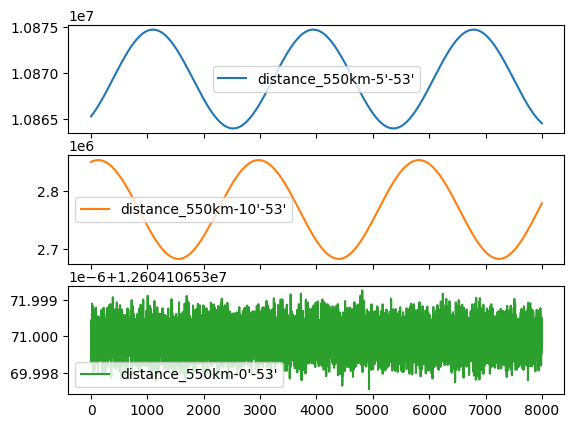

In [6]:
base_sattelite_positions[distance_suffixes].plot(subplots=True)

In [24]:
base_min_satellite = np.random.choice(df['satelliteId'].unique())
base_min_satellite

'Starlink-1-9'

In [25]:
base_min_sattelite_positions = df[df.satelliteId == base_min_satellite].reset_index()[['TimeStamp', 'X', 'Y', 'Z']]
min_distance_suffixes = []
for orbit in df['orbitId'].unique():
    orbit_satellites = df[df.orbitId == orbit].reset_index()[['TimeStamp', 'X', 'Y', 'Z']]
    orbit_satellites["distance"] = orbit_satellites.apply(lambda row: np.sqrt(
                    (row.X - base_min_sattelite_positions.X[row.name // NUMBER_OF_SATELLITES_PER_ORBIT])**2 + 
                    (row.Y - base_min_sattelite_positions.Y[row.name // NUMBER_OF_SATELLITES_PER_ORBIT])**2 + 
                    (row.Z - base_min_sattelite_positions.Z[row.name // NUMBER_OF_SATELLITES_PER_ORBIT])**2), axis=1)
    orbit_satellites_min_distance = orbit_satellites.groupby('TimeStamp').min().reset_index()
    base_min_sattelite_positions[f"min_distance_{orbit}"] = orbit_satellites_min_distance.distance
    min_distance_suffixes.append(f"min_distance_{orbit}")

base_min_sattelite_positions

,TimeStamp,X,Y,Z,min_distance_550km-5'-53',min_distance_550km-10'-53',min_distance_550km-0'-53'
0,0,-6.429031e+06,1.176203e+06,2.298514e+06,0.0,754841.216248,771261.975170
1,1000,-6.431829e+06,1.171752e+06,2.292953e+06,0.0,754984.522201,771371.095304
2,2000,-6.434619e+06,1.167299e+06,2.287389e+06,0.0,755127.596703,771479.920953
3,3000,-6.437401e+06,1.162845e+06,2.281822e+06,0.0,755270.439185,771588.451715
4,4000,-6.440176e+06,1.158389e+06,2.276253e+06,0.0,755413.049084,771696.687181
...,...,...,...,...,...,...,...
7996,7996000,3.919458e+06,-3.224391e+06,-4.715952e+06,0.0,663169.616784,685096.266454
7997,7997000,3.925744e+06,-3.221421e+06,-4.712753e+06,0.0,663328.460445,685274.183899
7998,7998000,3.932025e+06,-3.218447e+06,-4.709547e+06,0.0,663487.511776,685452.187614
7999,7999000,3.938301e+06,-3.215469e+06,-4.706336e+06,0.0,663646.769852,685630.276663


array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object)

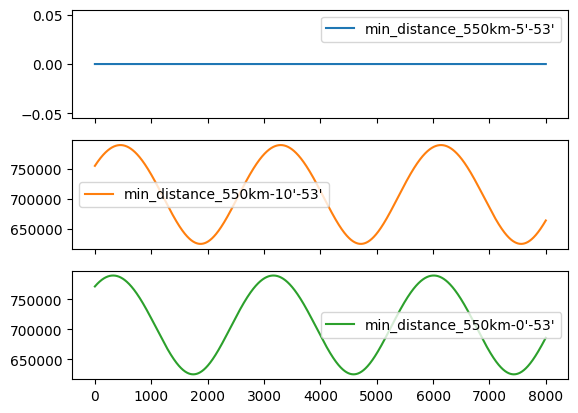

In [26]:
base_min_sattelite_positions[min_distance_suffixes].plot(subplots=True)